# Exploratory Data Analysis

This notebook hosts our exploratory data analysis works, from data sourcing and cleaning to inspection and visualization.

In [1]:
# Optional: in case the imports for the local folders/files fail
import os

if os.path.basename(os.getcwd()) == "data":
    os.chdir("../")

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from dukascopy_python.instruments import INSTRUMENT_FX_MAJORS_USD_JPY as USDJPY
from dukascopy_python.instruments import INSTRUMENT_IDX_AMERICA_E_SANDP_500 as SP500

from data import generate_input_data, data_utils

In [3]:
# Asset constants
LEADER = SP500
TARGET = USDJPY

## Data Fetching and Cleaning

In [4]:
# Loading FOMC calendar data
fomc_calendar_data = generate_input_data.get_fomc_calendar()
fomc_calendar_data.tail(10)  # sanity check

,Event,Survey,Actual,Prior,Revised,Ticker
2025-05-07 18:00:00+00:00,FOMC Rate Decision (Upper Bound),4.50%,4.50%,4.50%,--,FDTR Index
2025-06-18 18:00:00+00:00,FOMC Rate Decision (Upper Bound),4.50%,4.50%,4.50%,--,FDTR Index
2025-07-30 18:00:00+00:00,FOMC Rate Decision (Upper Bound),4.50%,4.50%,4.50%,--,FDTR Index
2025-09-17 18:00:00+00:00,FOMC Rate Decision (Upper Bound),4.25%,4.25%,4.50%,--,FDTR Index
2025-10-29 18:00:00+00:00,FOMC Rate Decision (Upper Bound),4.00%,4.00%,4.25%,--,FDTR Index
2025-12-10 19:00:00+00:00,FOMC Rate Decision (Upper Bound),3.75%,3.75%,4.00%,--,FDTR Index
2026-01-28 19:00:00+00:00,FOMC Rate Decision (Upper Bound),3.75%,3.75%,3.75%,--,FDTR Index
2026-03-18 18:00:00+00:00,FOMC Rate Decision (Upper Bound),3.75%,3.75%,3.75%,--,FDTR Index
2026-04-29 18:00:00+00:00,FOMC Rate Decision (Upper Bound),3.75%,3.75%,3.75%,--,FDTR Index
2026-06-17 18:00:00+00:00,FOMC Rate Decision (Upper Bound),3.75%,3.75%,3.75%,--,FDTR Index


In [5]:
# Loading the control group calendar
control_group_calendar = generate_input_data.build_control_calendar(fomc_calendar_data)
control_group_calendar.tail(10)  # sanity check

,matched_fomc_date
Timestamp,
2026-02-02 19:00:00+00:00,2026-01-28 19:00:00+00:00
2026-03-09 18:00:00+00:00,2026-03-18 18:00:00+00:00
2026-03-11 18:00:00+00:00,2026-03-18 18:00:00+00:00
2026-03-20 18:00:00+00:00,2026-03-18 18:00:00+00:00
2026-04-21 18:00:00+00:00,2026-04-29 18:00:00+00:00
2026-04-22 18:00:00+00:00,2026-04-29 18:00:00+00:00
2026-05-01 18:00:00+00:00,2026-04-29 18:00:00+00:00
2026-06-12 18:00:00+00:00,2026-06-17 18:00:00+00:00
2026-06-22 18:00:00+00:00,2026-06-17 18:00:00+00:00


In [6]:
# Main function to pull and clean our data
def pull_tick_data(leader, target, calendar_data):
    """Pulls and aligns tick data for the input cross-asset pairs"""
    datasets = []
    valid_dates = []

    for timestamp in calendar_data.index:
        event_window_start = timestamp - pd.Timedelta(minutes=5)
        event_window_end = timestamp + pd.Timedelta(minutes=15)

        leader_data = generate_input_data.fetch_tick_data(
            event_window_start, event_window_end, leader
        )
        target_data = generate_input_data.fetch_tick_data(
            event_window_start, event_window_end, target
        )

        # We skip the loop if Dukascopy returns missing/empty data
        if leader_data.empty or target_data.empty:
            print(f"Warning: Incomplete data for event {timestamp}. Skipping.")
            continue

        # Aligning timestamps via outer join
        dataset = pd.concat([leader_data, target_data], axis=1, join="outer", sort=True)
        price_cols = dataset.columns.tolist()

        # Creating a strict 1-second grid
        sec_grid = pd.date_range(
            start=dataset.index.min(), end=dataset.index.max(), freq="s"
        )
        # Reindexing the df on the sec_by_sec_grid (forces missing seconds into the index)
        aligned_dataset = dataset.reindex(sec_grid)

        # Flagging genuine vs forward-filled quotes per asset
        genuine_flags = aligned_dataset[price_cols].notna()
        genuine_flags.columns = [f"{c}_genuine" for c in price_cols]
        # Forward filling to propagate the last traded price, then dropping initial NaNs
        aligned_dataset = aligned_dataset.ffill()
        aligned_dataset = pd.concat([aligned_dataset, genuine_flags], axis=1)
        aligned_dataset = aligned_dataset.dropna(subset=price_cols)

        datasets.append(aligned_dataset)
        valid_dates.append(timestamp)

    datasets_dict = dict(zip(valid_dates, datasets))
    return datasets_dict

In [7]:
# Getting the FOMC group data
fomc_data = pull_tick_data(LEADER, TARGET, fomc_calendar_data)
fomc_data  # sanity check

{Timestamp('2021-07-28 18:00:00+0000', tz='UTC'):                            E_SandP-500   USD/JPY  E_SandP-500_genuine  \
 2021-07-28 17:55:07+00:00    4394.6075  110.0765                False   
 2021-07-28 17:55:08+00:00    4394.8015  110.0765                 True   
 2021-07-28 17:55:09+00:00    4394.8015  110.0765                False   
 2021-07-28 17:55:10+00:00    4394.8015  110.0765                False   
 2021-07-28 17:55:11+00:00    4394.8015  110.0765                False   
 ...                                ...       ...                  ...   
 2021-07-28 18:14:55+00:00    4402.7925  110.1475                False   
 2021-07-28 18:14:56+00:00    4402.9420  110.1445                 True   
 2021-07-28 18:14:57+00:00    4403.2970  110.1440                 True   
 2021-07-28 18:14:58+00:00    4403.3240  110.1425                 True   
 2021-07-28 18:14:59+00:00    4403.3240  110.1440                False   
 
                            USD/JPY_genuine  
 2021-07-28 17:

In [8]:
# Getting the control group data
control_group_data = pull_tick_data(LEADER, TARGET, control_group_calendar)
control_group_data  # sanity check

{Timestamp('2021-07-20 18:00:00+0000', tz='UTC'):                            E_SandP-500   USD/JPY  E_SandP-500_genuine  \
 2021-07-20 17:55:17+00:00    4323.3015  109.8585                 True   
 2021-07-20 17:55:18+00:00    4323.0015  109.8585                 True   
 2021-07-20 17:55:19+00:00    4323.0015  109.8585                False   
 2021-07-20 17:55:20+00:00    4322.7955  109.8585                 True   
 2021-07-20 17:55:21+00:00    4322.7955  109.8580                False   
 ...                                ...       ...                  ...   
 2021-07-20 18:14:54+00:00    4329.5090  109.8510                False   
 2021-07-20 18:14:55+00:00    4329.2940  109.8510                 True   
 2021-07-20 18:14:56+00:00    4329.2940  109.8510                False   
 2021-07-20 18:14:57+00:00    4329.2940  109.8510                False   
 2021-07-20 18:14:58+00:00    4329.0015  109.8510                 True   
 
                            USD/JPY_genuine  
 2021-07-20 17:

In [9]:
# Saving to avoid querying the API every time
FOMC_DATA_DIR = Path(rf"data/fomc_tick_data")
CONTROL_DATA_DIR = Path(rf"data/control_group_tick_data")

In [10]:
data_utils.save_datasets_dict(fomc_data, FOMC_DATA_DIR)
data_utils.save_datasets_dict(control_group_data, CONTROL_DATA_DIR)

## Data Analysis

In [11]:
fomc_data = data_utils.load_datasets_into_dict(FOMC_DATA_DIR)
control_group_data = data_utils.load_datasets_into_dict(CONTROL_DATA_DIR)

In [12]:
def set_plot_style():
    """Helper function to apply consistent plotting styles throughout"""
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["DejaVu Serif"],
            "axes.edgecolor": "#333333",
            "axes.linewidth": 1.0,
            "axes.grid": True,
            "grid.color": "#cccccc",
            "grid.linestyle": "--",
            "grid.linewidth": 0.6,
            "grid.alpha": 0.6,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
        }
    )

#### Stale vs non-stale quotes analysis

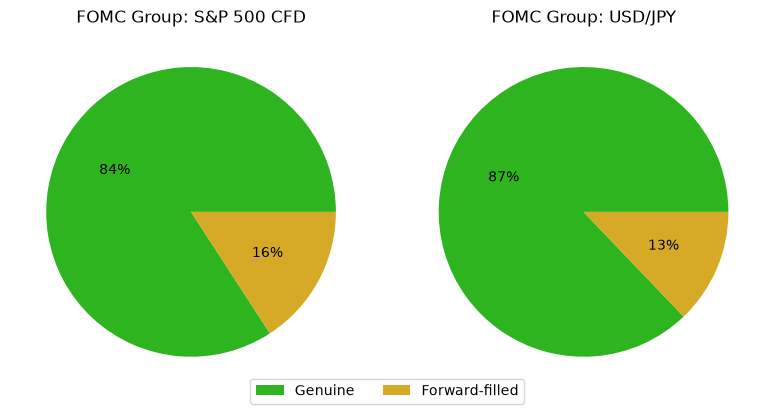

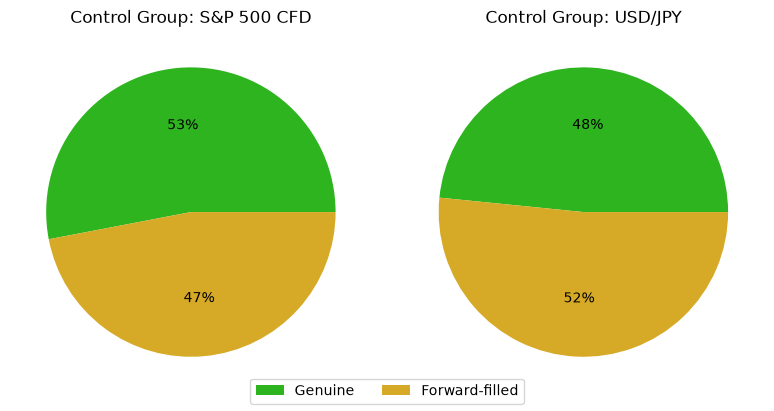

In [13]:
def plot_genuine_quote_pies(
    datasets_dict, group_name, leader_col="leader", target_col="target"
):
    """Pie charts of genuine vs forward-filled quotes for input group (FOMC or Control)"""
    assets = [leader_col, target_col]
    fig, axes = plt.subplots(1, len(assets), figsize=(4 * len(assets), 4))
    colors = ["#2eb41f", "#d6aa27"]

    for ax, asset in zip(axes, assets):
        flags = pd.concat(df[f"{asset}_genuine"] for df in datasets_dict.values())
        counts = flags.value_counts()
        wedges, _, _ = ax.pie(
            [counts.get(True, 0), counts.get(False, 0)],
            autopct="%1.0f%%",
            colors=colors,
        )
        ax.set_title(
            f"{group_name}: {asset if asset != "E_SandP-500" else "S&P 500 CFD"}"
        )

    fig.legend(wedges, ["Genuine", "Forward-filled"], loc="lower center", ncol=2)
    plt.tight_layout()
    plt.show()


plot_genuine_quote_pies(fomc_data, "FOMC Group", LEADER, TARGET)
plot_genuine_quote_pies(control_group_data, "Control Group", LEADER, TARGET)

In [14]:
def summarize_stale_run_lengths(
    datasets_dict, leader_col="leader", target_col="target"
):
    """Returns longest and average consecutive forward-filled run, in seconds, per asset,
    pooled across all events"""
    rows = []
    for asset in [leader_col, target_col]:
        run_lengths = []
        for df in datasets_dict.values():
            stale = (~df[f"{asset}_genuine"]).astype(int)
            group_id = (stale != stale.shift()).cumsum()
            lengths = stale.groupby(group_id).sum()
            run_lengths.extend(lengths[lengths > 0].tolist())
        rows.append(
            {
                "asset": f"{asset if asset != "E_SandP-500" else "S&P 500 CFD"}",
                "longest_run_s": max(run_lengths) if run_lengths else 0,
                "mean_run_s": np.mean(run_lengths) if run_lengths else 0,
                "n_runs": len(run_lengths),
            }
        )
    return pd.DataFrame(rows)


summarize_stale_run_lengths(fomc_data, LEADER, TARGET)

,asset,longest_run_s,mean_run_s,n_runs
0,S&P 500 CFD,51,1.959473,3874
1,USD/JPY,43,1.983269,3108


#### Self-dependence/ Autocorrelation Patterns post FOMC

In [15]:
def _asset_label(asset):
    """Asset label helper (for formatting)"""
    return "S&P 500 CFD" if asset == "E_SandP-500" else asset


def diagnose_series_self_dependence(
    datasets_dict,
    series_name,
    max_lag_seconds=30,
    shock_pre_seconds=30,
    shock_post_seconds=150,
    min_obs=30,
    n_neighbors=3,
    random_state=42,
    genuine_only=False,
):
    """Checks whether `series_name` (e.g. 'E_SandP-500') has meaningful
    self-dependence at short lags, and whether it's linear or not. Note:
    genuine_only=True drops forward-filled (stale) quotes before computing
    returns, using the "genuine" flag"""
    windowed_returns = []
    for event_time, df in datasets_dict.items():
        shock_start = event_time - pd.Timedelta(seconds=shock_pre_seconds)
        shock_end = event_time + pd.Timedelta(seconds=shock_post_seconds)
        if genuine_only:
            genuine_df = df[df[f"{series_name}_genuine"]]
            returns = np.log(genuine_df[series_name]).diff().dropna()
        else:
            returns = np.log(df[series_name]).diff().dropna()
        windowed_returns.append(returns.loc[shock_start:shock_end])

    lags = np.arange(1, max_lag_seconds + 1)
    linear_acf = np.full(len(lags), np.nan)
    sq_acf = np.full(len(lags), np.nan)
    mi_vals = np.full(len(lags), np.nan)

    for j, lag in enumerate(lags):
        pairs = [
            pd.concat([r, r.shift(lag)], axis=1, keys=["now", "past"]).dropna()
            for r in windowed_returns
        ]
        aligned = pd.concat(pairs)
        if len(aligned) < min_obs:
            continue

        now, past = aligned["now"], aligned["past"]
        linear_acf[j] = now.corr(past)
        sq_acf[j] = (now**2).corr(past**2)
        mi_vals[j] = mutual_info_regression(
            past.values.reshape(-1, 1),
            now.values,
            n_neighbors=n_neighbors,
            random_state=random_state,
        )[0]

    lag_unit = "genuine ticks" if genuine_only else "s"
    _plot_self_dependence(
        series_name, lags, linear_acf, sq_acf, mi_vals, lag_unit=lag_unit
    )


def _plot_self_dependence(series_name, lags, linear_acf, sq_acf, mi_vals, lag_unit="s"):
    label = _asset_label(series_name)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    panels = [
        (
            linear_acf,
            "tab:blue",
            f"{label}: linear ACF of raw returns",
            "Autocorrelation",
        ),
        (
            sq_acf,
            "tab:orange",
            f"{label}: ACF of squared returns\n(volatility clustering)",
            "Autocorrelation",
        ),
        (
            mi_vals,
            "tab:green",
            f"{label}: MI(r(t), r(t-lag))\n(any dependence shape)",
            "Mutual information (nats)",
        ),
    ]
    for ax, (values, color, title, ylabel) in zip(axes, panels):
        ax.plot(
            lags,
            values,
            marker="o",
            color=color,
            linewidth=1.6,
            markersize=4.5,
            markeredgecolor="white",
            markeredgewidth=0.6,
        )
        ax.axhline(0, color="#666666", linewidth=0.9, zorder=0)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel(f"Lag ({lag_unit})", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.tick_params(axis="both", labelsize=11)
    plt.tight_layout()
    plt.show()

#### Leader:

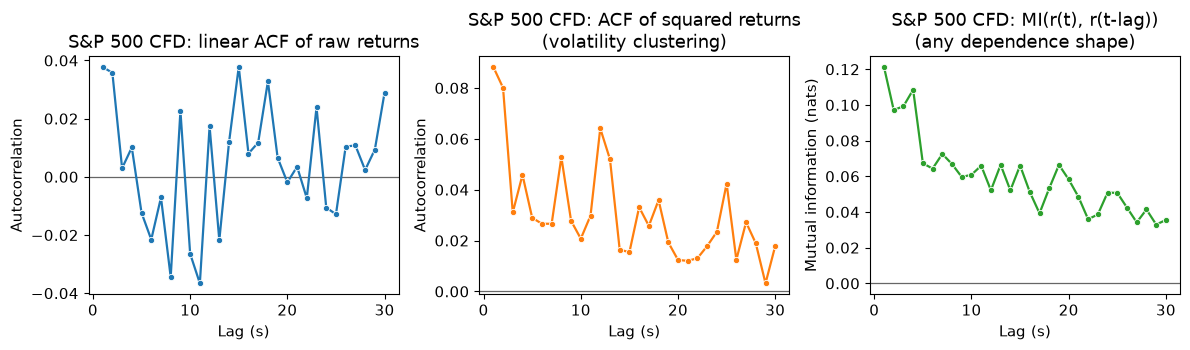

In [16]:
diagnose_series_self_dependence(fomc_data, LEADER)

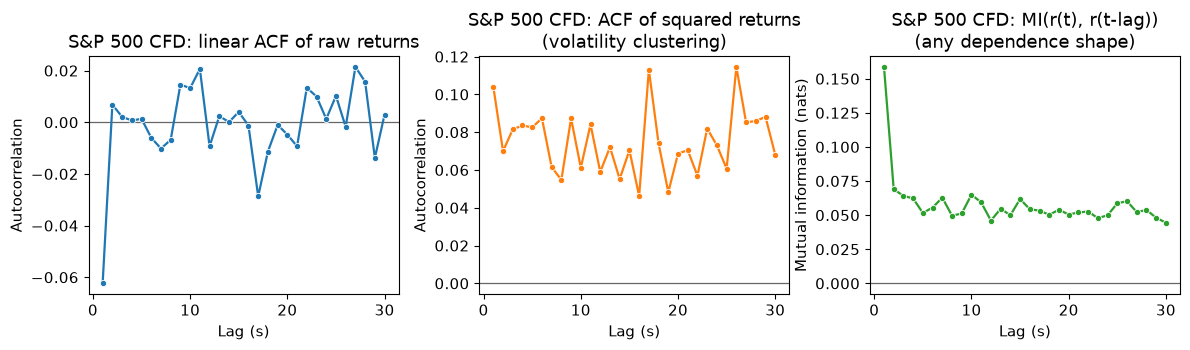

In [17]:
diagnose_series_self_dependence(control_group_data, LEADER)

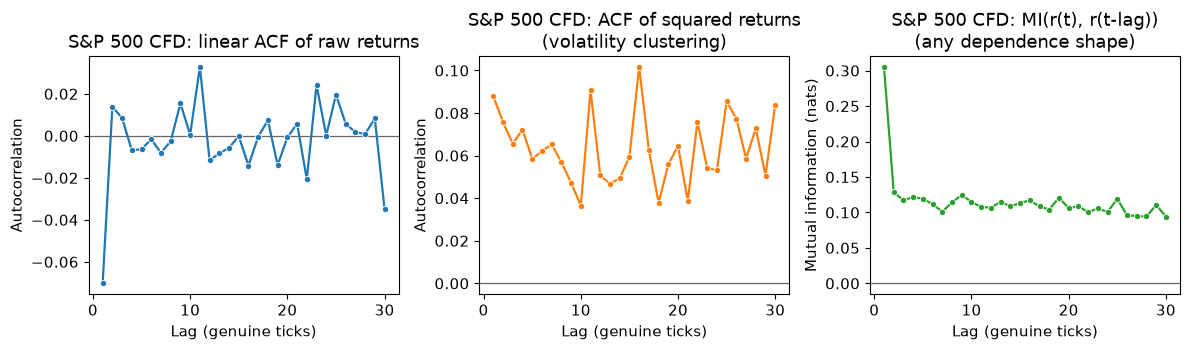

In [18]:
# Extra check to see if the self-dependence patterns are influenced
# by stale ticks creating infrequent price updates
diagnose_series_self_dependence(control_group_data, LEADER, genuine_only=True)

#### Target:

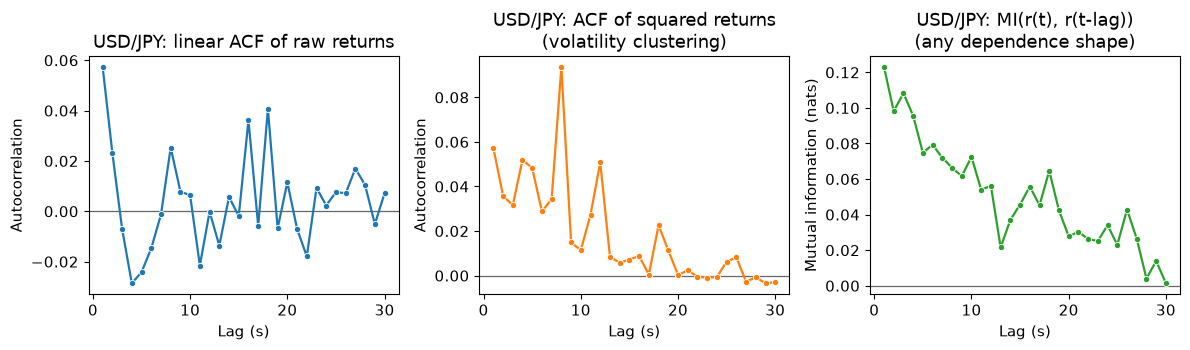

In [19]:
diagnose_series_self_dependence(fomc_data, TARGET)

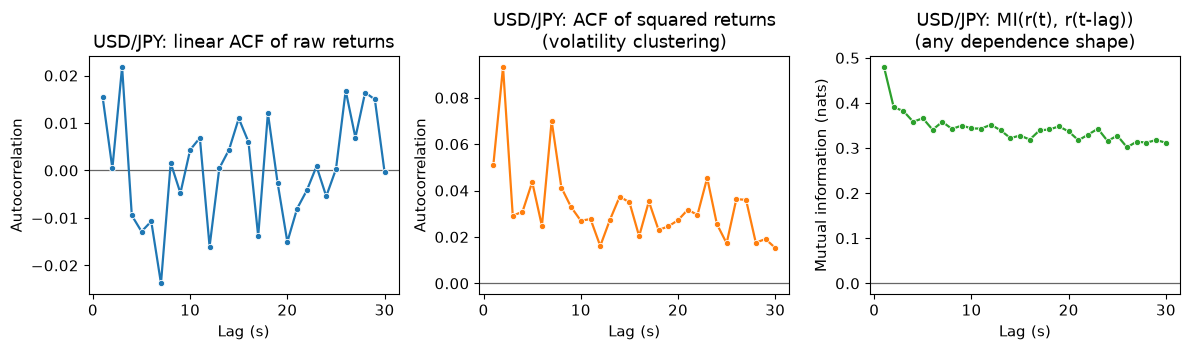

In [20]:
diagnose_series_self_dependence(control_group_data, TARGET)

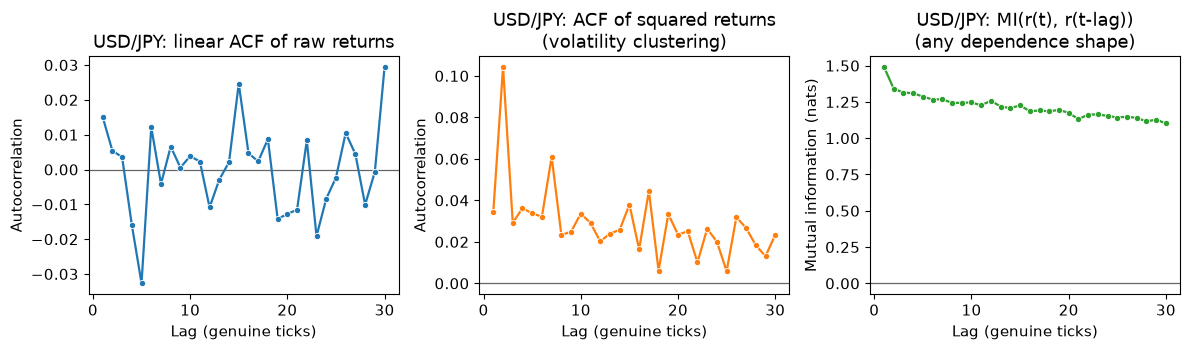

In [21]:
# Extra check to see if the self-dependence patterns are influenced
# by stale ticks creating infrequent price updates
diagnose_series_self_dependence(control_group_data, TARGET, genuine_only=True)

#### Gaussianity

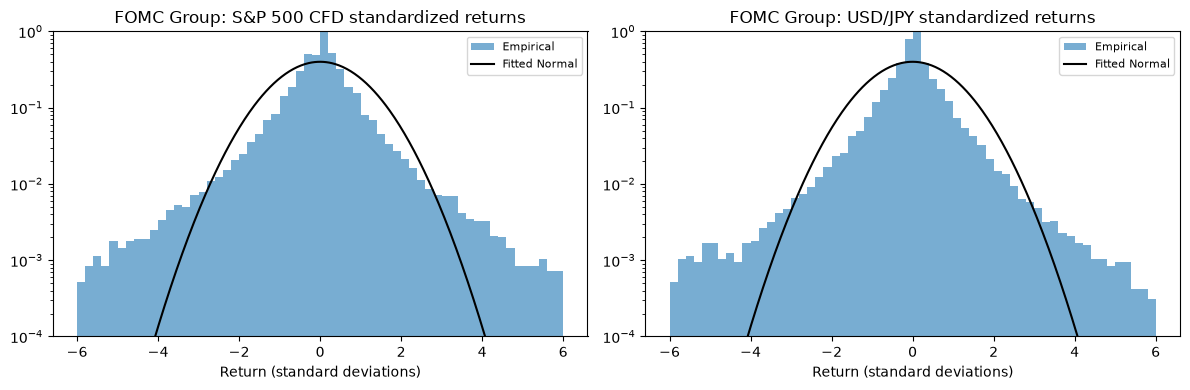

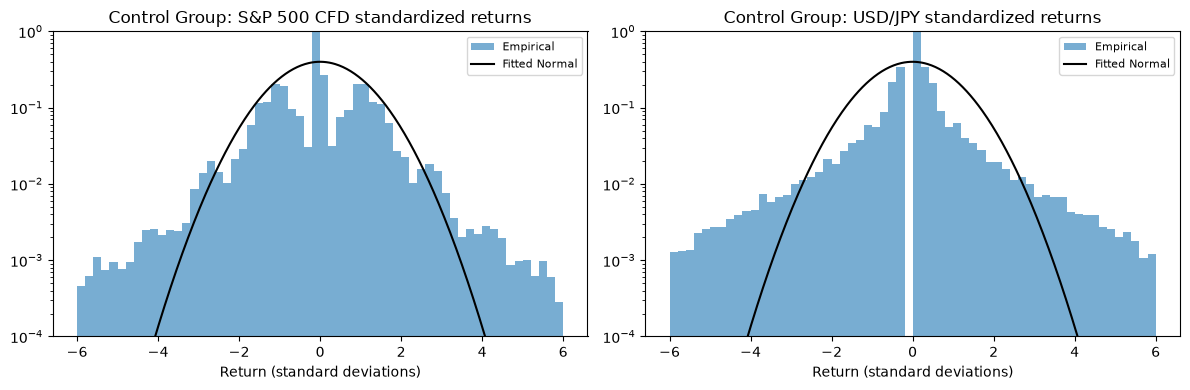

In [22]:
def plot_fat_tails(
    datasets_dict,
    group_name,
    leader_col="leader",
    target_col="target",
    bins=60,
    n_std=6,
):
    """Plots a histogram of standardized 1-second log returns (z-scores) vs. a fitted
    standard Gaussian"""
    assets = [leader_col, target_col]
    fig, axes = plt.subplots(1, len(assets), figsize=(6 * len(assets), 4))

    x = np.linspace(-n_std, n_std, 500)
    gaussian_pdf = np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

    for ax, asset in zip(axes, assets):
        returns = pd.concat(
            np.log(df[asset]).diff().dropna() for df in datasets_dict.values()
        )
        z_scores = (
            returns - returns.mean()
        ) / returns.std()  # mean/std computed on the full sample

        ax.hist(
            z_scores,
            bins=bins,
            range=(-n_std, n_std),
            density=True,
            alpha=0.6,
            color="tab:blue",
            label="Empirical",
        )
        ax.plot(x, gaussian_pdf, color="black", linewidth=1.5, label="Fitted Normal")

        ax.set_yscale("log")
        ax.set_ylim(1e-4, 1)
        ax.set_title(
            f"{group_name}: {f"{asset if asset != "E_SandP-500" else "S&P 500 CFD"}"} standardized returns"
        )
        ax.set_xlabel("Return (standard deviations)")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def summarize_return_moments(
    datasets_dict, group_name, leader_col="leader", target_col="target"
):
    """Computes skewness and excess kurtosis"""
    rows = []
    for asset in [leader_col, target_col]:
        returns = pd.concat(
            np.log(df[asset]).diff().dropna() for df in datasets_dict.values()
        )
        n = len(returns)
        z = (returns - returns.mean()) / returns.std()
        skewness = (z**3).mean()
        kurtosis = (z**4).mean()  # normal = 3
        excess_kurtosis = kurtosis - 3
        rows.append(
            {
                "group": group_name,
                "asset": f"{asset if asset != "E_SandP-500" else "S&P 500 CFD"}",
                "n": n,
                "skewness": skewness,
                "excess_kurtosis": excess_kurtosis,
            }
        )
    return pd.DataFrame(rows)


plot_fat_tails(fomc_data, "FOMC Group", LEADER, TARGET)
plot_fat_tails(control_group_data, "Control Group", LEADER, TARGET)

return_moments_fomc = summarize_return_moments(fomc_data, "FOMC Group", LEADER, TARGET)
return_moments_control = summarize_return_moments(
    control_group_data, "Control Group", LEADER, TARGET
)

In [23]:
return_moments_fomc

,group,asset,n,skewness,excess_kurtosis
0,FOMC Group,S&P 500 CFD,47897,-1.669723,106.179648
1,FOMC Group,USD/JPY,47897,-1.061333,342.743757


In [24]:
return_moments_control

,group,asset,n,skewness,excess_kurtosis
0,Control Group,S&P 500 CFD,143429,1.408101,93.634697
1,Control Group,USD/JPY,143429,0.146775,44.813207


#### Liquidity and volatility stats

#### Spreads:

In [25]:
def pull_second_by_second_spread_data(
    leader, target, calendar_data, window_before_min=5, window_after_min=5
):
    """Pulls and aligns spread data at the 1 second frequency for each event"""
    datasets = {}
    for event_time in calendar_data.index:
        start = event_time - pd.Timedelta(minutes=window_before_min)
        end = event_time + pd.Timedelta(minutes=window_after_min)

        leader_spread = generate_input_data.fetch_spreads(start, end, leader)[
            "spread"
        ].rename(leader)
        target_spread = generate_input_data.fetch_spreads(start, end, target)[
            "spread"
        ].rename(target)

        dataset = pd.concat(
            [leader_spread, target_spread], axis=1, join="outer", sort=True
        )
        if dataset.empty:
            continue
        sec_grid = pd.date_range(dataset.index.min(), dataset.index.max(), freq="s")
        aligned = dataset.reindex(sec_grid).ffill().dropna()
        if not aligned.empty:
            datasets[event_time] = aligned
    return datasets

In [26]:
fomc_spread_data = pull_second_by_second_spread_data(LEADER, TARGET, fomc_calendar_data)
control_group_spread_data = pull_second_by_second_spread_data(
    LEADER, TARGET, control_group_calendar
)

In [27]:
# Instead of looking at absolute spreads, we look at them on a relative basis
def build_spread_ratio_table(datasets_dict, group_name, cols):
    rows = []
    for event_time, df in datasets_dict.items():
        seconds_from_event = (df.index - event_time).total_seconds().astype(int)
        baseline_mask = seconds_from_event < 0
        for col in cols:
            baseline = df.loc[baseline_mask, col].mean()
            if pd.isna(baseline) or baseline == 0:
                continue
            rows.append(
                pd.DataFrame(
                    {
                        "event_ts": event_time,
                        "group": group_name,
                        "asset": col,
                        "seconds_from_event": seconds_from_event,
                        "spread_ratio": (df[col] / baseline).values,
                    }
                )
            )
    return pd.concat(rows, ignore_index=True)


def plot_spreads(
    fomc_dict, control_dict, leader, target, smooth_window=5, window_minutes=5
):
    """Plots relative spreads for fomc group and control group, averaged
    out across all events/control windows, zoomed to +/- window_minutes"""
    full_table = pd.concat(
        [
            build_spread_ratio_table(fomc_dict, "FOMC", cols=(leader, target)),
            build_spread_ratio_table(control_dict, "Control", cols=(leader, target)),
        ],
        ignore_index=True,
    )

    window_s = window_minutes * 60
    zoomed = full_table[full_table["seconds_from_event"].abs() <= window_s]

    means = (
        zoomed.groupby(["group", "asset", "seconds_from_event"])["spread_ratio"]
        .mean()
        .reset_index(name="mean")
    )
    means["mean_smooth"] = means.groupby(["group", "asset"])["mean"].transform(
        lambda s: s.rolling(smooth_window, center=True, min_periods=1).mean()
    )

    assets, colors = [leader, target], {"FOMC": "#b42e1f", "Control": "#7f7f7f"}
    fig, axes = plt.subplots(1, len(assets), figsize=(6 * len(assets), 4))
    for ax, asset in zip(axes, assets):
        for group in ["FOMC", "Control"]:
            sub = means[
                (means["asset"] == asset) & (means["group"] == group)
            ].sort_values("seconds_from_event")
            n_events = zoomed[(zoomed["asset"] == asset) & (zoomed["group"] == group)][
                "event_ts"
            ].nunique()
            x = sub["seconds_from_event"] / 60
            ax.plot(
                x,
                sub["mean_smooth"],
                color=colors[group],
                linewidth=1.5,
                label=f"{group} (n={n_events})",
            )
        label = asset if asset != "E_SandP-500" else "S&P 500 CFD"
        ax.axhline(1, color="black", linestyle="--", linewidth=1)
        ax.axvline(0, color="black", linestyle=":", linewidth=1)
        ax.set_title(f"{label}: spread relative to pre-event baseline")
        ax.set_xlabel("Minutes from announcement")
        ax.set_ylabel("Spread / pre-event mean spread")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return full_table

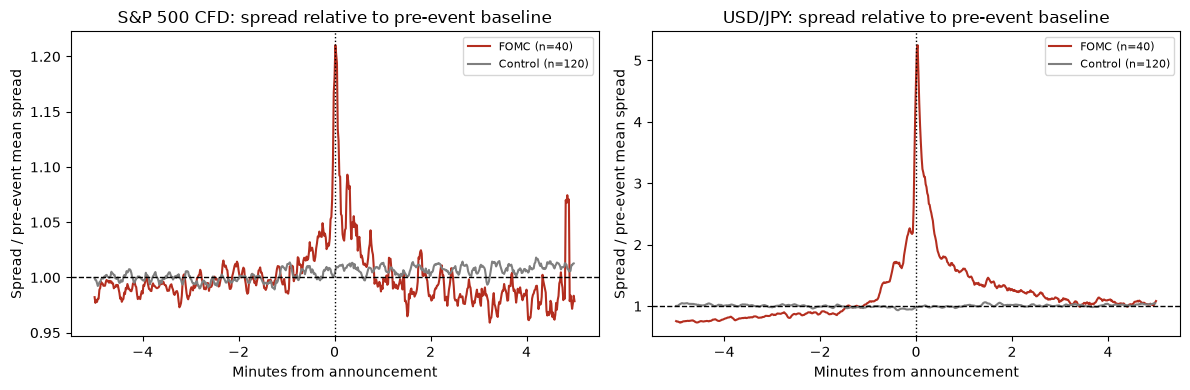

In [28]:
relative_spreads_table = plot_spreads(
    fomc_spread_data, control_group_spread_data, LEADER, TARGET
)

In [29]:
# Box plots set-up
COLORS = {"FOMC": "#b42e1f", "Control": "#7f7f7f"}


def _plot_boxplots_by_group(summary, value_col, ylabel, title_fn, leader, target):
    """Generic helper code to help us plot every boxplot"""
    assets = [leader, target]
    fig, axes = plt.subplots(1, len(assets), figsize=(6 * len(assets), 6))
    for ax, asset in zip(axes, assets):
        box_data, box_labels = [], []
        for group in ["FOMC", "Control"]:
            vals = summary[(summary["asset"] == asset) & (summary["group"] == group)][
                value_col
            ]
            box_data.append(vals.values)
            box_labels.append(f"{group}\n(n={len(vals)})")
        try:
            bp = ax.boxplot(
                box_data,
                tick_labels=box_labels,
                patch_artist=True,
                showfliers=False,
                widths=0.5,
            )
        except TypeError:
            bp = ax.boxplot(
                box_data,
                labels=box_labels,
                patch_artist=True,
                showfliers=False,
                widths=0.5,
            )
        for patch, group in zip(bp["boxes"], ["FOMC", "Control"]):
            patch.set_facecolor(COLORS[group])
            patch.set_alpha(0.5)
        ax.set_title(title_fn(asset), pad=12)
        ax.set_ylabel(ylabel)
        ax.margins(x=0.25)
    plt.tight_layout(pad=2.5, w_pad=4.0)
    plt.show()
    return summary

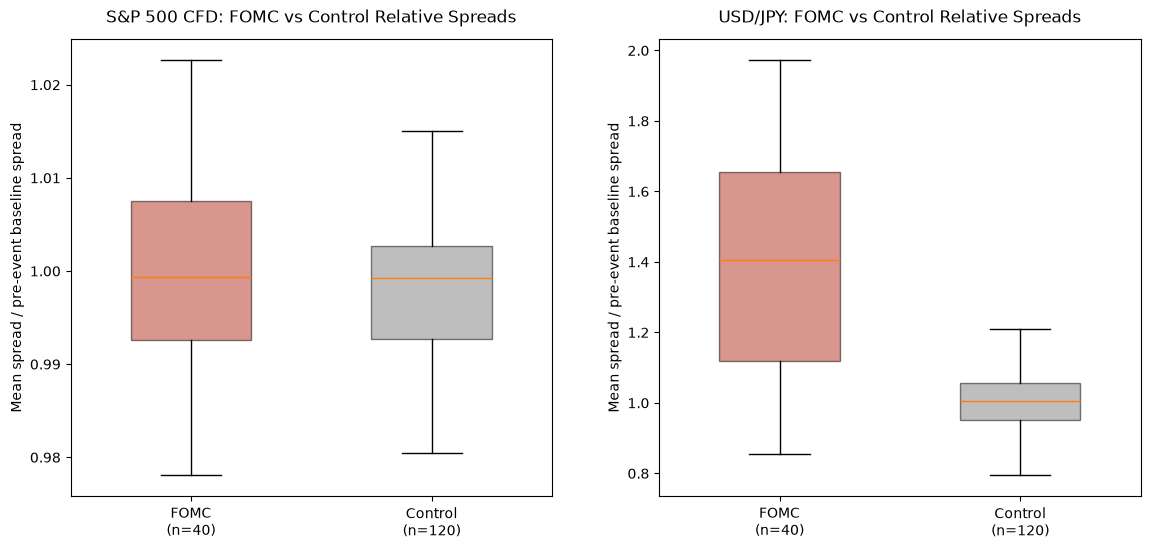

In [30]:
def summarize_spread_ratio(full_table, window_after_min=5):
    """Summarizes spread ratio table"""
    window_end_s = window_after_min * 60
    windowed = full_table[
        (full_table["seconds_from_event"] >= 0)
        & (full_table["seconds_from_event"] <= window_end_s)
    ]
    return (
        windowed.groupby(["event_ts", "group", "asset"])["spread_ratio"]
        .mean()
        .reset_index(name="mean_spread_ratio")
    )


def plot_spread_boxplots(full_table, leader, target, window_after_min=5):
    """Plots a boxplot of spreads for fomc vs control"""
    summary = summarize_spread_ratio(full_table, window_after_min)
    title_fn = lambda a: f"{_asset_label(a)}: FOMC vs Control Relative Spreads"
    _plot_boxplots_by_group(
        summary,
        "mean_spread_ratio",
        "Mean spread / pre-event baseline spread",
        title_fn,
        leader,
        target,
    )


plot_spread_boxplots(relative_spreads_table, LEADER, TARGET)

Price updates:

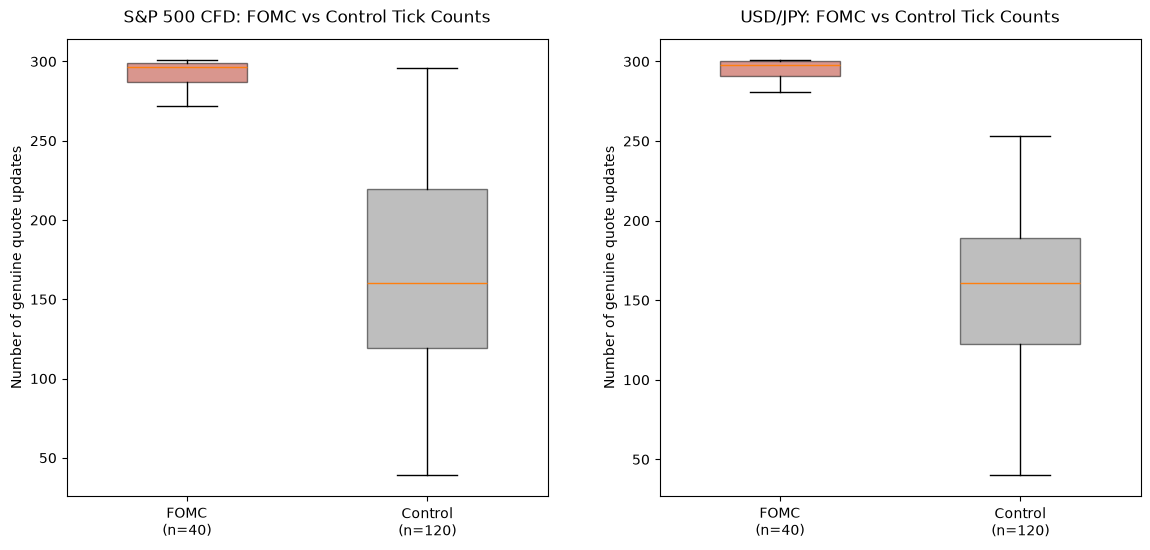

In [31]:
def build_tick_count_summary_table(
    datasets_dict, group_name, leader, target, window_after_min=5
):
    """Builds summary table for tick count data"""
    rows = []
    window_end_s = window_after_min * 60
    for event_time, df in datasets_dict.items():
        seconds_from_event = (df.index - event_time).total_seconds()
        mask = (seconds_from_event >= 0) & (seconds_from_event <= window_end_s)
        for col in (leader, target):
            rows.append(
                {
                    "event_ts": event_time,
                    "group": group_name,
                    "asset": col,
                    "tick_count": df.loc[mask, f"{col}_genuine"].sum(),
                }
            )
    return pd.DataFrame(rows)


def plot_tick_count_boxplots(
    fomc_dict, control_dict, leader, target, window_after_min=5
):
    """Plots a boxplot for tick counts for fomc vs control"""
    summary = pd.concat(
        [
            build_tick_count_summary_table(
                fomc_dict, "FOMC", leader, target, window_after_min
            ),
            build_tick_count_summary_table(
                control_dict, "Control", leader, target, window_after_min
            ),
        ],
        ignore_index=True,
    )
    title_fn = lambda a: f"{_asset_label(a)}: FOMC vs Control Tick Counts"
    _plot_boxplots_by_group(
        summary,
        "tick_count",
        "Number of genuine quote updates",
        title_fn,
        leader,
        target,
    )


plot_tick_count_boxplots(fomc_data, control_group_data, LEADER, TARGET)

Volatility:

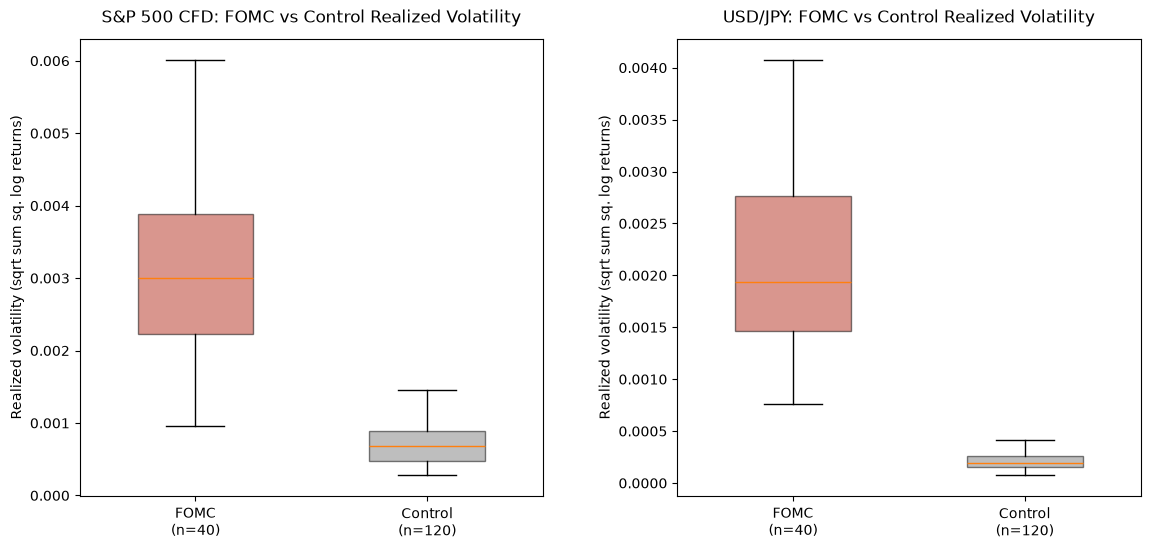

In [32]:
def build_volatility_summary_table(
    datasets_dict, group_name, leader, target, window_after_min=5
):
    """Builds summary table for volatility data"""
    rows = []
    window_end_s = window_after_min * 60
    for event_time, df in datasets_dict.items():
        seconds_from_event = (df.index - event_time).total_seconds()
        mask = (seconds_from_event >= 0) & (seconds_from_event <= window_end_s)
        window_df = df.loc[mask]
        for col in (leader, target):
            log_returns = np.log(window_df[col]).diff().dropna()
            realized_vol = np.sqrt((log_returns**2).sum())
            rows.append(
                {
                    "event_ts": event_time,
                    "group": group_name,
                    "asset": col,
                    "realized_vol": realized_vol,
                }
            )
    return pd.DataFrame(rows)


def plot_volatility_boxplots(
    fomc_dict, control_dict, leader, target, window_after_min=5
):
    """Plots a boxplot of volatility for fomc vs control"""
    summary = pd.concat(
        [
            build_volatility_summary_table(
                fomc_dict, "FOMC", leader, target, window_after_min
            ),
            build_volatility_summary_table(
                control_dict, "Control", leader, target, window_after_min
            ),
        ],
        ignore_index=True,
    )
    title_fn = lambda a: f"{_asset_label(a)}: FOMC vs Control Realized Volatility"
    _plot_boxplots_by_group(
        summary,
        "realized_vol",
        "Realized volatility (sqrt sum sq. log returns)",
        title_fn,
        leader,
        target,
    )


plot_volatility_boxplots(fomc_data, control_group_data, LEADER, TARGET)